Curtosis excess :15.13   (normal = 0)
Asimetría       :-0.32    (normal = 0)


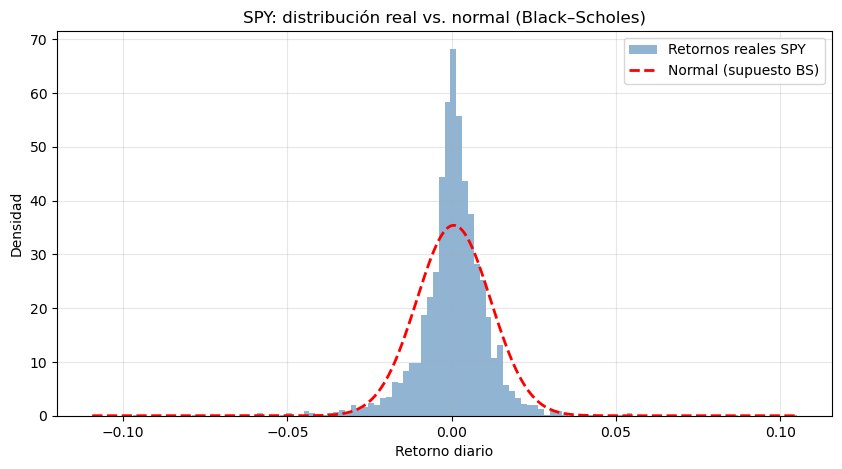

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess :{kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       :{skew(retornos):.2f}    (normal = 0)")

x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

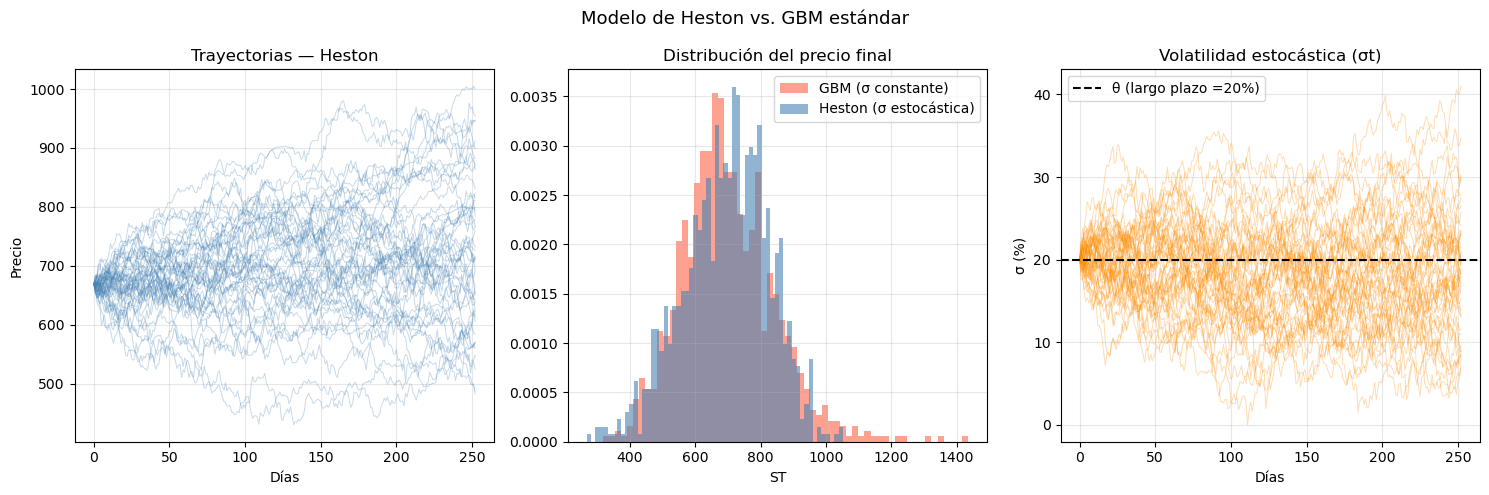

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# --- Comparación: GBM estándar vs. Heston ---
sigma_const = 0.20
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trayectorias
for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Distribución final: GBM vs Heston
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Evolución de la varianza
for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

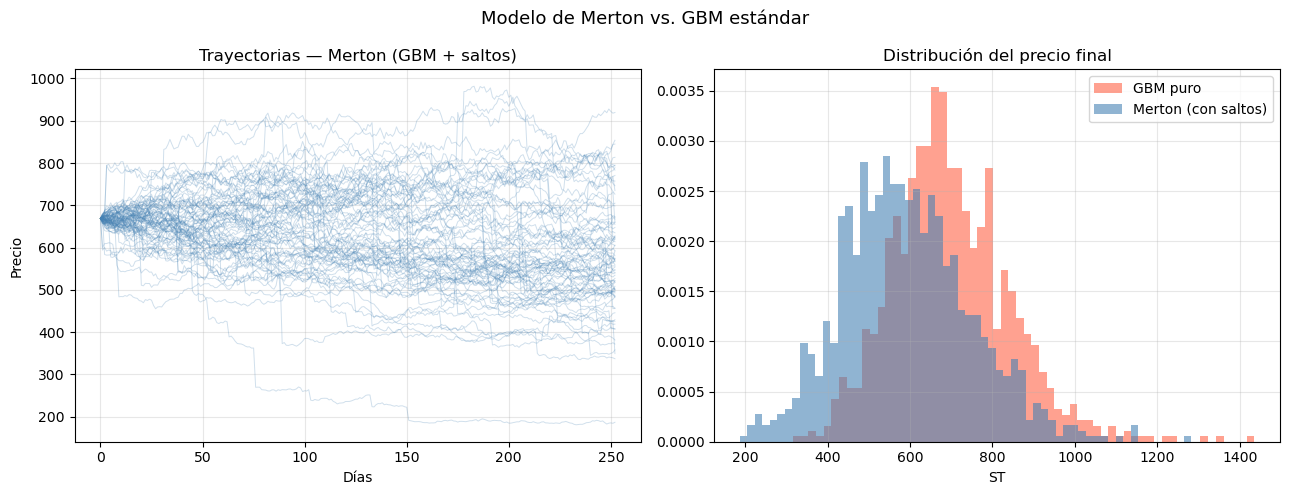

In [3]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias — algunos saltos visibles
for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Comparación distribución final
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

# Simulaciones de Heston

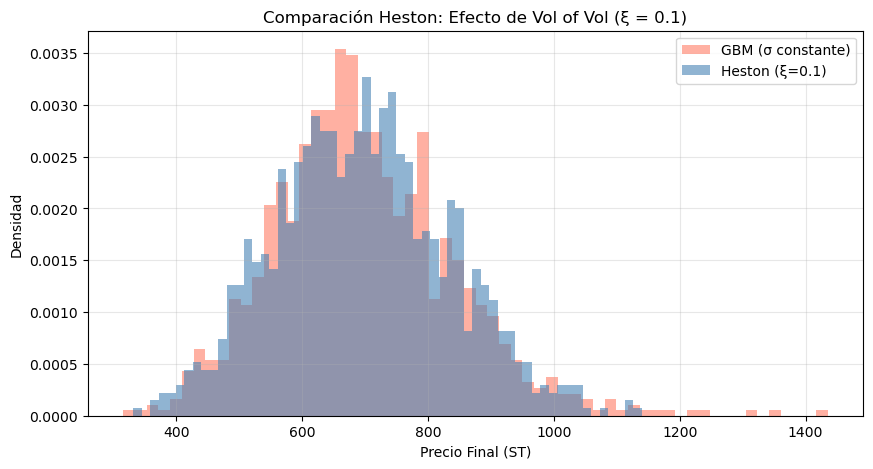

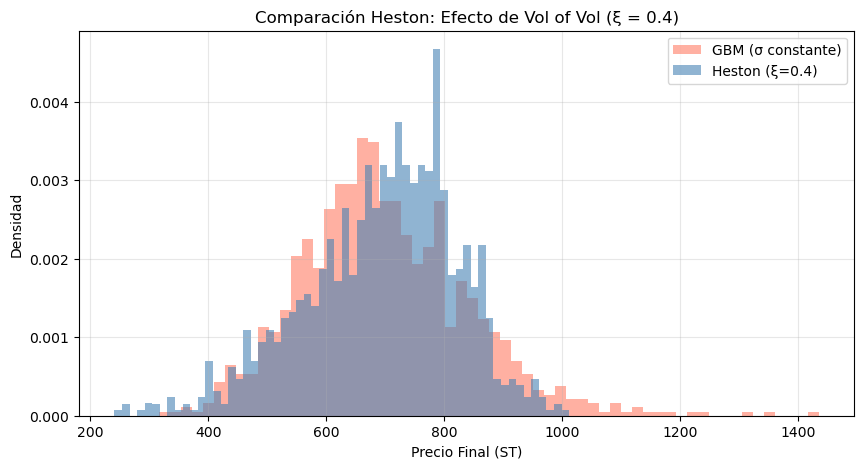

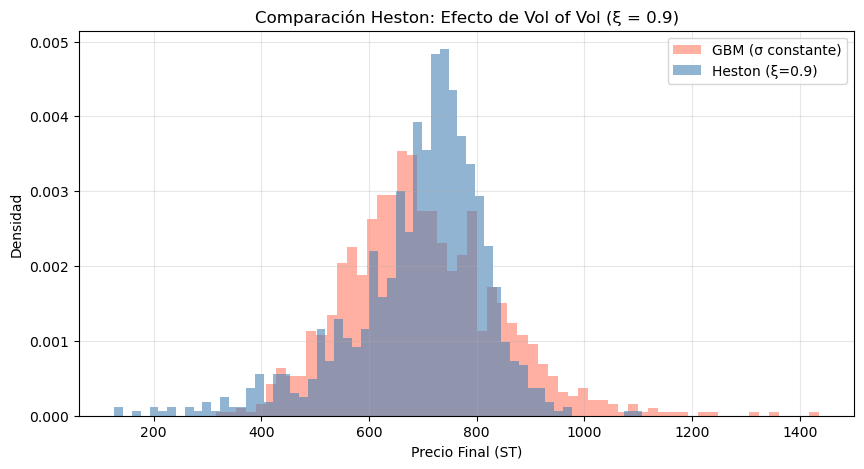

In [4]:
# Definir los valores de xi a probar
valores_xi = [0.1, 0.4, 0.9]

for xi_val in valores_xi:
    # Simulamos con el xi actual
    S_h, v_h = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M)
    
    # Graficamos
    plt.figure(figsize=(10, 5))
    plt.hist(S_gbm[:, -1], bins=60, density=True, alpha=0.5, color='tomato', label='GBM (σ constante)')
    plt.hist(S_h[:, -1], bins=60, density=True, alpha=0.6, color='steelblue', label=f'Heston (ξ={xi_val})')
    
    plt.title(f'Comparación Heston: Efecto de Vol of Vol (ξ = {xi_val})')
    plt.xlabel('Precio Final (ST)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Simulaciones de Merton

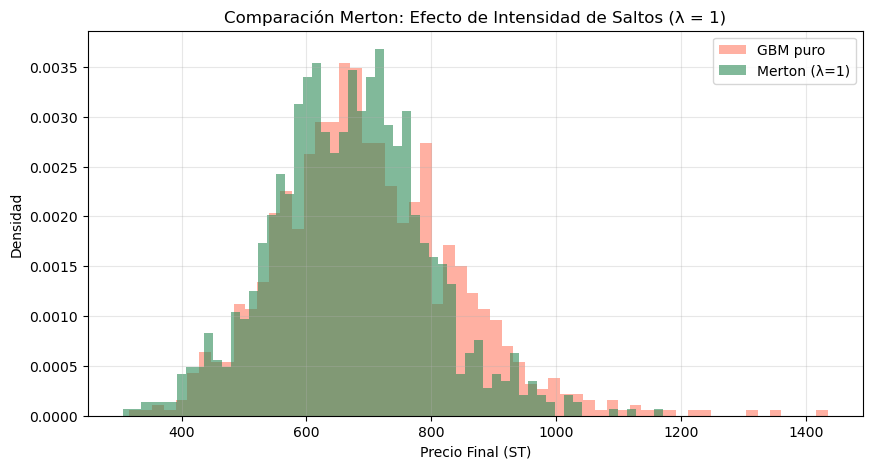

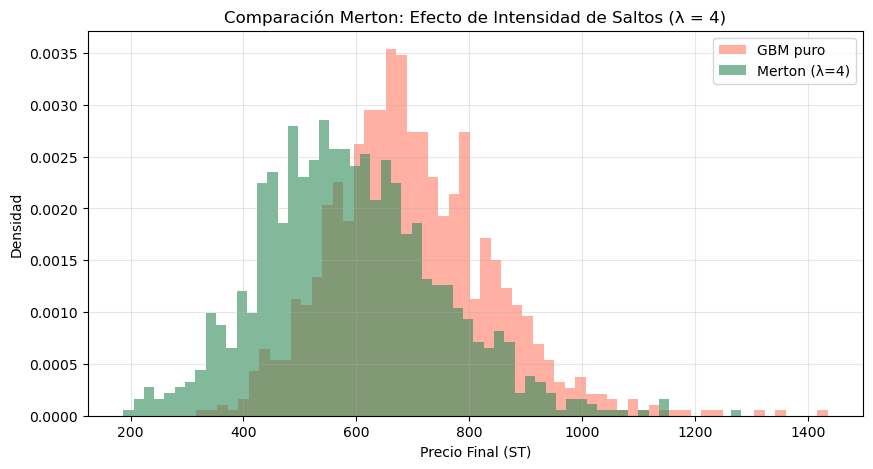

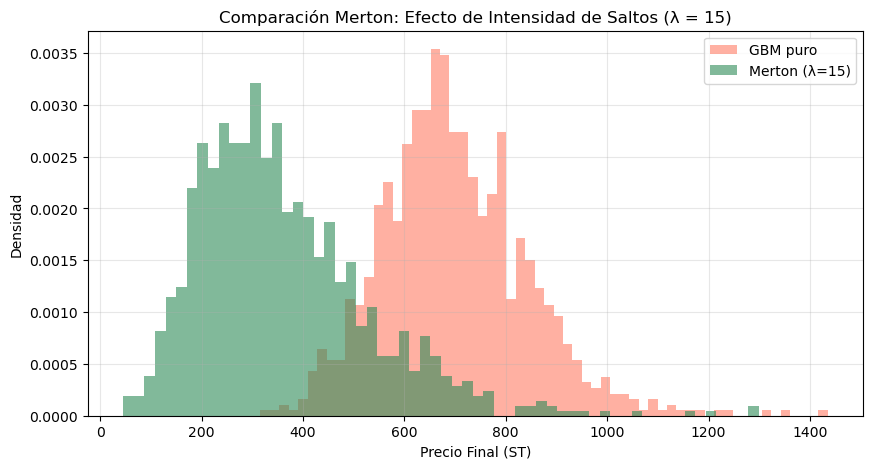

In [5]:
# Definir los valores de lambda a probar
valores_lam = [1, 4, 15]

for lam_val in valores_lam:
    # Simulamos con el lambda actual
    S_m = simular_merton(S0, mu, sigma, lam_val, mu_j, sigma_j, T, N, M)
    
    # Graficamos
    plt.figure(figsize=(10, 5))
    plt.hist(S_gbm[:, -1], bins=60, density=True, alpha=0.5, color='tomato', label='GBM puro')
    plt.hist(S_m[:, -1], bins=60, density=True, alpha=0.6, color='seagreen', label=f'Merton (λ={lam_val})')
    
    plt.title(f'Comparación Merton: Efecto de Intensidad de Saltos (λ = {lam_val})')
    plt.xlabel('Precio Final (ST)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

 ## Preguntas:
 
 En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?
 
la distribución del precio final se ve más dispersa y con colas más largas. El skew se vuelve más negativo supongo que por que hay mayor volatilidad
 
En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?

Pues se ve como menos continua, y mucho más ancha y se recorrió hacia la izquierda, basicamente es mas probable que el resultado sea negativo


Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?

Pues el precio estaría subestimado porque ignoaría esas fat tails

Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?

Que los saltos se pueden agrupar en períodos

¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?

Pues porque es muy simple y eso no quita que sea efectivo
